# Create Synthetic Data

In [19]:
import pandas as pd
import random


START = 0
STOP = 100_000_000
TOTAL = 50_000_000




# def create_inorder_data(start:int, stop:int, total:int)->pd.DataFrame:
#     data = [i for i in range(start, start + total)]
#     df = pd.DataFrame({"values": data})
#     return df

def create_random_data(start, stop, total)->pd.DataFrame:
    data = random.sample(range(start, stop), total)
    df = pd.DataFrame({"values": data})
    return df


# create_inorder_data(START, STOP, TOTAL).to_csv("data/inorder_list.csv", index=False)
# df = create_random_data(START, STOP, TOTAL)
df.to_csv("data/samples/random_list.csv", index=False)
df.sort_values(by="values",ascending = False).to_csv("data/samples/inorder_list.csv", index=False)

#  Graphs

In [7]:
import pandas as pd
def get_avl_data():
    # Search
    avl_indored = pd.read_csv("data/results/avl_inorder_search_results.csv")
    avl_random = pd.read_csv("data/results/avl_random_search_results.csv")
    df_search = pd.concat([avl_indored, avl_random])
    df_search["run_type"] = df_search.run_type.map( {'inorder_avl_search': 'AVL In Order Search', 'random_avl_search': 'AVL Random Search'})
    df_search["tree_size"] = df_search["tree_size"]/1_000_000
    df_search.rename(columns={"ops_count": "operations_count"}, inplace=True)
    del(avl_indored, avl_random)

    # delete
    avl_indored = pd.read_csv("data/results/avl_inorder_delete_results.csv")
    avl_random = pd.read_csv("data/results/avl_random_delete_results.csv")
    df_delete = pd.concat([avl_indored, avl_random])
    df_delete["run_type"] = df_delete.run_type.map( {'inorder_avl_delete': 'AVL In Order Delete', 'random_avl_delete': 'AVL Random Delete'})
    df_delete["tree_size"] = df_search["tree_size"]/1_000_000

    del(avl_indored, avl_random)

    # insert
    avl_indored = pd.read_csv("data/results/avl_inorder_results.csv")
    avl_random = pd.read_csv("data/results/avl_random_results.csv")
    df_insert = pd.concat([avl_indored, avl_random])
    df_insert["run_type"] = df_insert.run_type.map( {'inorder_avl_insertion': 'AVL In Order Insertion', 'random_avl_insertion': 'AVL Random Insertion'})
    df_insert["tree_size"] = df_insert["total_nodes"]/1_000_000
    return {
        "search":df_search,
        "delete": df_delete,
        "insert": df_insert
    }

def get_bin_data():
    # Search
    bin_indored = pd.read_csv("data/results/bin_inorder_search_results.csv")
    bin_random = pd.read_csv("data/results/bin_random_search_results.csv")
    df_search = pd.concat([bin_indored, bin_random])
    df_search["run_type"] = df_search.run_type.map( {'inorder_bin_search': 'BST Inorder Search', 'random_bin_search': 'BST Random Search'})
    df_search["tree_size"] = df_search["tree_size"]/1_000_000
    df_search.rename(columns={"ops_count": "operations_count"}, inplace=True)
    del(bin_indored, bin_random)

    # delete
    bin_indored = pd.read_csv("data/results/bin_inorder_delete_results.csv")
    bin_random = pd.read_csv("data/results/bin_random_delete_results.csv")
    df_delete = pd.concat([bin_indored, bin_random])
    df_delete["run_type"] = df_delete.run_type.map( {'inorder_bin_delete': 'BST Inorder Delete', 'random_bin_delete': 'BST Random Delete'})
    df_delete["tree_size"] = df_search["tree_size"]/1_000_000

    del(bin_indored, bin_random)

    # insert
    bin_indored = pd.read_csv("data/results/bin_inorder_results.csv")
    bin_random = pd.read_csv("data/results/bin_random_results.csv")
    df_insert = pd.concat([bin_indored, bin_random])
    df_insert["run_type"] = df_insert.run_type.map( {'inorder_bin_insertion': 'BST In Order Insertion', 'random_bin_insertion': 'BST Random Insertion'})
    df_insert["tree_size"] = df_insert["total_nodes"]/1_000_000
    return {
        "search":df_search,
        "delete": df_delete,
        "insert": df_insert
    }



## AVL Search

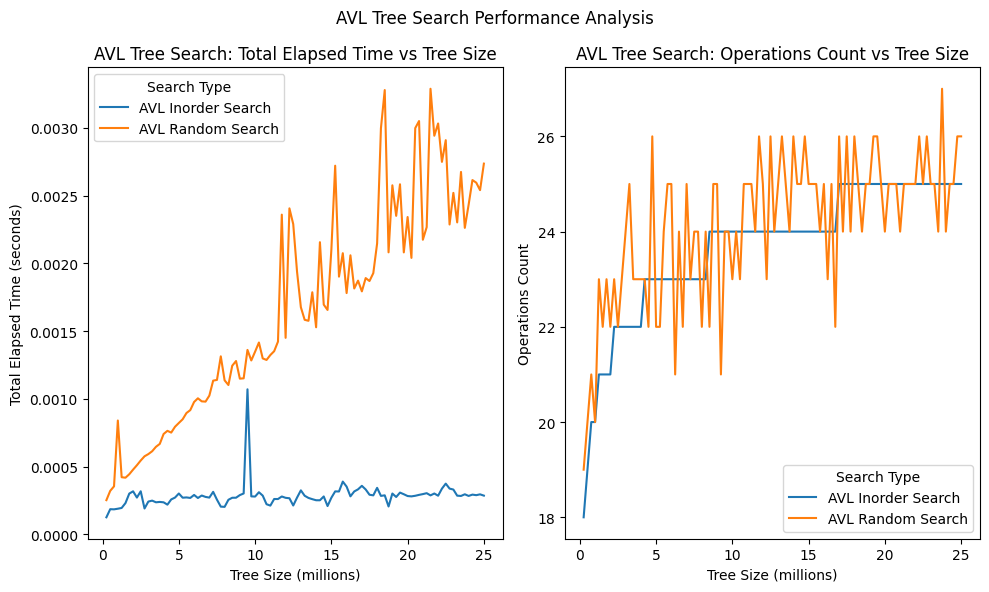

In [ ]:
df = get_avl_data()["search"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

sns.lineplot(x=df["tree_size"], y=df["total_elapsed_time"], hue=df["run_type"], ax=axes[0])
axes[0].set_ylabel("Total Elapsed Time (seconds)")
axes[0].set_xlabel("Tree Size (millions)")
axes[0].set_title("AVL Tree Search: Total Elapsed Time vs Tree Size")

sns.lineplot(x=df["tree_size"], y=df["operations_count"], hue=df["run_type"], ax=axes[1])
axes[1].set_ylabel("Operations Count")
axes[1].set_xlabel("Tree Size (millions)")
axes[1].set_title("AVL Tree Search: Operations Count vs Tree Size")

axes[0].legend(title="Search Type")
axes[1].legend(title="Search Type")
plt.suptitle("AVL Tree Search Performance Analysis")

plt.tight_layout()
plt.savefig("data/plots/avl_search_performance_analysis.png")
plt.show()

del(df)
    

## AVL Deletion

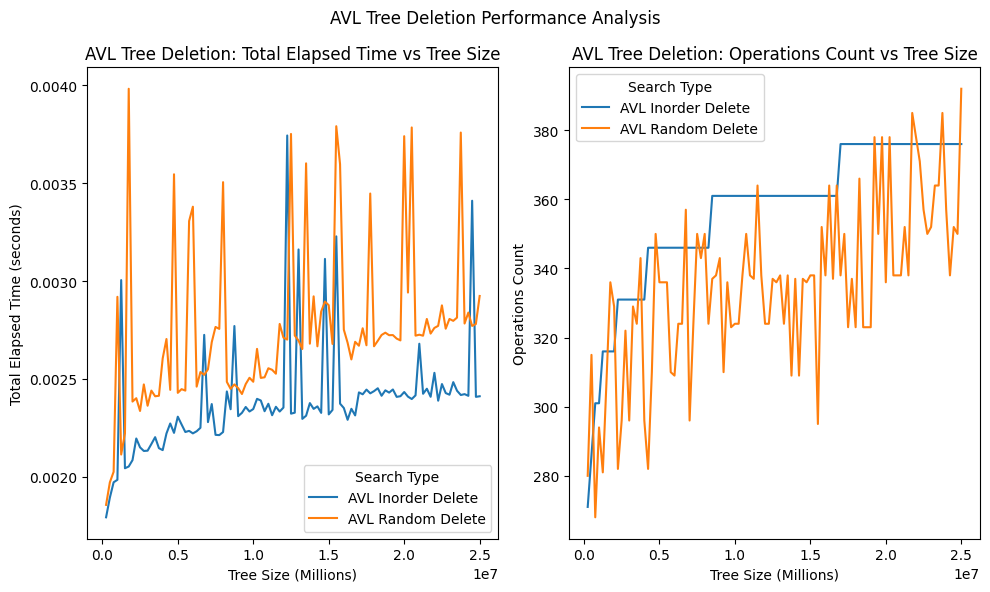

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt



df = get_avl_data()["delete"]



fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

sns.lineplot(x=df["tree_size"], y=df["total_elapsed_time"], hue=df["run_type"], ax=axes[0])
axes[0].set_ylabel("Total Elapsed Time (seconds)")
axes[0].set_xlabel("Tree Size (Millions)")
axes[0].set_title("AVL Tree Deletion: Total Elapsed Time vs Tree Size")

sns.lineplot(x=df["tree_size"], y=df["ops_count"], hue=df["run_type"], ax=axes[1])
axes[1].set_ylabel("Operations Count")
axes[1].set_xlabel("Tree Size (Millions)")
axes[1].set_title("AVL Tree Deletion: Operations Count vs Tree Size")

axes[0].legend(title="Search Type")
axes[1].legend(title="Search Type")
plt.suptitle("AVL Tree Deletion Performance Analysis")
plt.tight_layout()
plt.savefig("data/plots/avl_deletion_performance_analysis.png")
plt.show()

del(df)
    

###  AVL Insert Plot

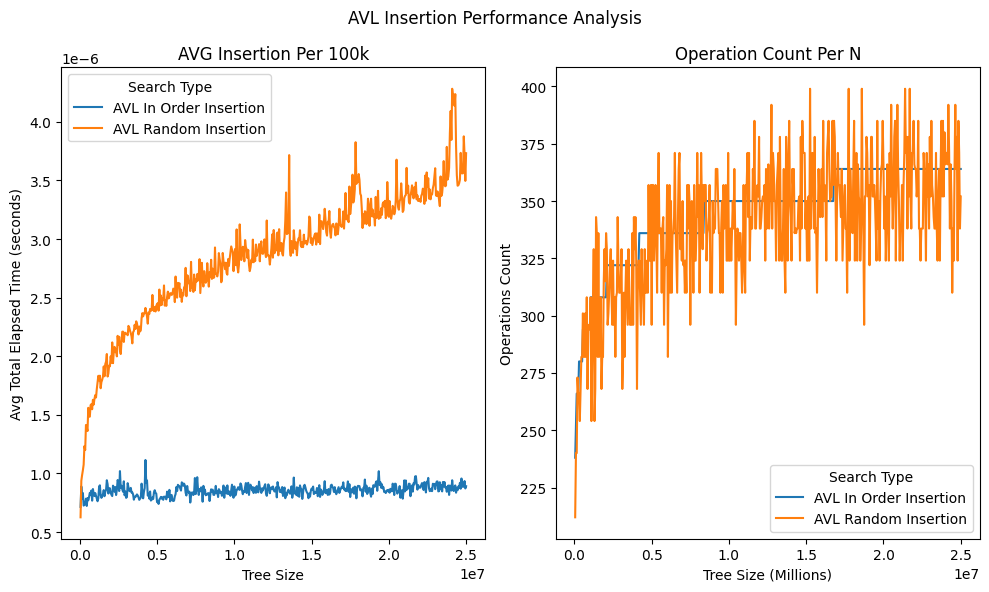

In [52]:

import seaborn as sns
import matplotlib.pyplot as plt



df = get_avl_data()["insert"]


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

sns.lineplot(x=df["total_nodes"], y=df["avg_time_per_insert"], hue=df["run_type"], ax=axes[0])
axes[0].set_ylabel("Avg Total Elapsed Time (seconds)")
axes[0].set_xlabel("Tree Size")
axes[0].set_title("AVG Insertion Per 100k")

sns.lineplot(x=df["total_nodes"], y=df["operation_count"], hue=df["run_type"], ax=axes[1])
axes[1].set_ylabel("Operations Count")
axes[1].set_xlabel("Tree Size (Millions)")
axes[1].set_title("Operation Count Per N")

axes[0].legend(title="Search Type")
axes[1].legend(title="Search Type")

plt.suptitle("AVL Insertion Performance Analysis")
plt.tight_layout()
plt.savefig("data/plots/avl_insertion_performance_analysis.png")
plt.show()

del(df)
    





# Binary Analysis

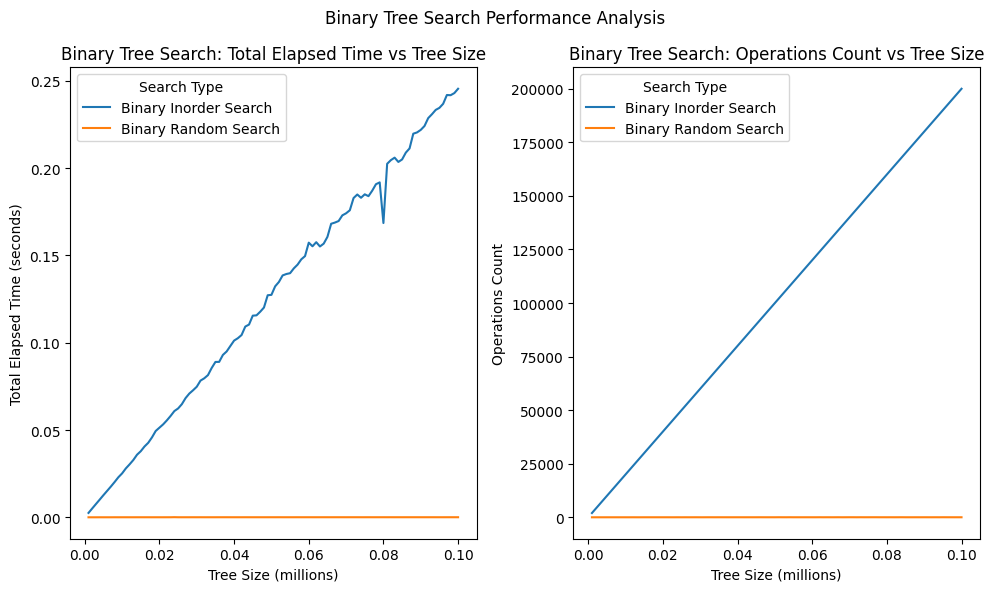

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt



avl_indored = pd.read_csv("data/results/bin_inorder_search_results.csv")
avl_random = pd.read_csv("data/results/bin_random_search_results.csv")

df = pd.concat([avl_indored, avl_random])
df["run_type"] = df.run_type.map( {'inorder_bin_search': 'Binary Inorder Search', 'random_bin_search': 'Binary Random Search'})
df["tree_size"] = df["tree_size"]/1_000_000
df.rename(columns={"ops_count": "operations_count"}, inplace=True)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

sns.lineplot(x=df["tree_size"], y=df["total_elapsed_time"], hue=df["run_type"], ax=axes[0])
axes[0].set_ylabel("Total Elapsed Time (seconds)")
axes[0].set_xlabel("Tree Size (millions)")
axes[0].set_title("Binary Tree Search: Total Elapsed Time vs Tree Size")

sns.lineplot(x=df["tree_size"], y=df["operations_count"], hue=df["run_type"], ax=axes[1])
axes[1].set_ylabel("Operations Count")
axes[1].set_xlabel("Tree Size (millions)")
axes[1].set_title("Binary Tree Search: Operations Count vs Tree Size")

axes[0].legend(title="Search Type")
axes[1].legend(title="Search Type")
plt.suptitle("Binary Tree Search Performance Analysis")
plt.tight_layout()
plt.savefig("data/plots/binary_search_performance_analysis.png")
plt.show()

del(avl_indored, avl_random)
del(df)
    

# Binary Delete

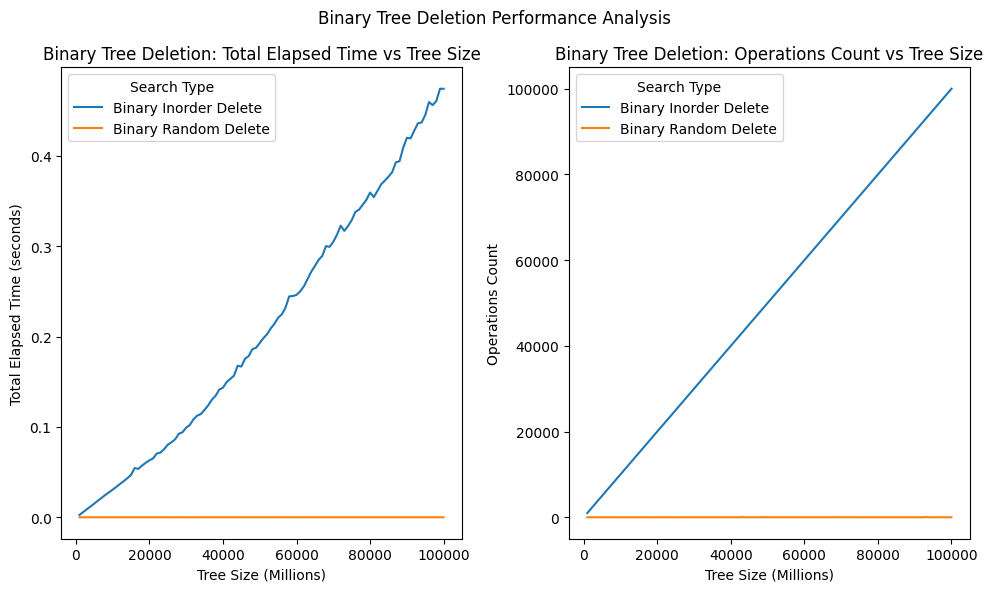

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



avl_indored = pd.read_csv("data/results/bin_inorder_delete_results.csv")
avl_random = pd.read_csv("data/results/bin_random_delete_results.csv")
df = pd.concat([avl_indored, avl_random])
df["run_type"] = df.run_type.map( {'inorder_bin_delete': 'Binary Inorder Delete', 'random_bin_delete': 'Binary Random Delete'})
df.rename(columns={"ops_count": "operations_count"}, inplace=True)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

sns.lineplot(x=df["tree_size"], y=df["total_elapsed_time"], hue=df["run_type"], ax=axes[0])
axes[0].set_ylabel("Total Elapsed Time (seconds)")
axes[0].set_xlabel("Tree Size (Millions)")
axes[0].set_title("Binary Tree Deletion: Total Elapsed Time vs Tree Size")

sns.lineplot(x=df["tree_size"], y=df["operations_count"], hue=df["run_type"], ax=axes[1])
axes[1].set_ylabel("Operations Count")
axes[1].set_xlabel("Tree Size (Millions)")
axes[1].set_title("Binary Tree Deletion: Operations Count vs Tree Size")

axes[0].legend(title="Search Type")
axes[1].legend(title="Search Type")
plt.suptitle("Binary Tree Deletion Performance Analysis")
plt.tight_layout()
plt.savefig("data/plots/binary_deletion_performance_analysis.png")
plt.show()

del(avl_indored, avl_random)
del(df)
    

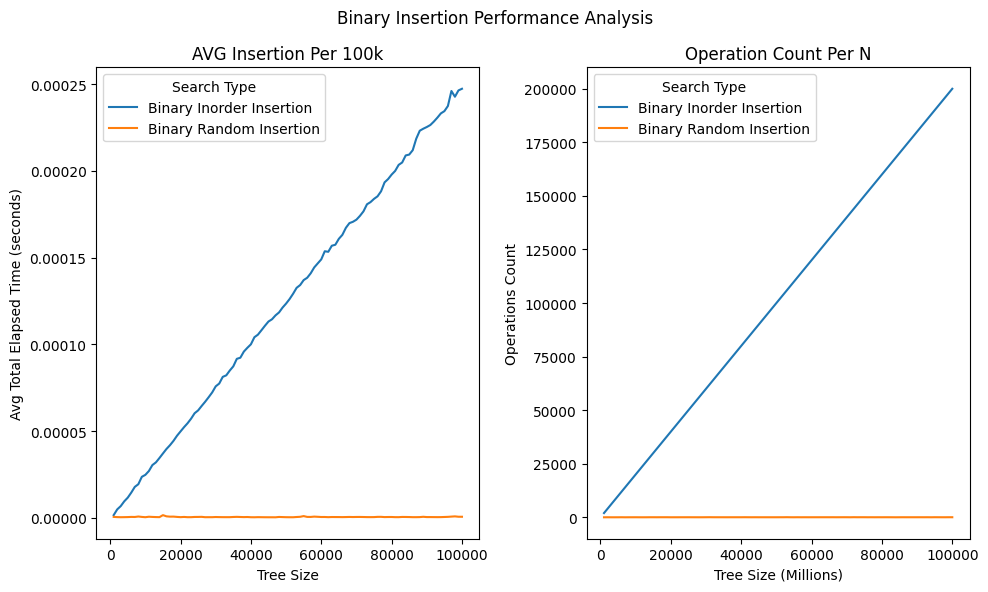

In [82]:

import seaborn as sns
import matplotlib.pyplot as plt



avl_indored = pd.read_csv("data/results/bin_inorder_results.csv")
avl_random = pd.read_csv("data/results/bin_random_results.csv")

df = pd.concat([avl_indored, avl_random])


df["run_type"] = df.run_type.map( {'inorder_bin_insertion': 'Binary Inorder Insertion', 'random_bin_insertion': 'Binary Random Insertion'})
df.rename(columns={"operation_count": "operations_count"}, inplace=True)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

sns.lineplot(x=df["total_nodes"], y=df["avg_time_per_insert"], hue=df["run_type"], ax=axes[0])
axes[0].set_ylabel("Avg Total Elapsed Time (seconds)")
axes[0].set_xlabel("Tree Size")
axes[0].set_title("AVG Insertion Per 100k")

sns.lineplot(x=df["total_nodes"], y=df["operations_count"], hue=df["run_type"], ax=axes[1])
axes[1].set_ylabel("Operations Count")
axes[1].set_xlabel("Tree Size (Millions)")
axes[1].set_title("Operation Count Per N")

axes[0].legend(title="Search Type")
axes[1].legend(title="Search Type")
plt.suptitle("Binary Insertion Performance Analysis")
plt.tight_layout()
plt.savefig("data/plots/binary_insertion_performance_analysis.png")
plt.show()

del(avl_indored, avl_random)
del(df)
    





# Operation Counts

avl

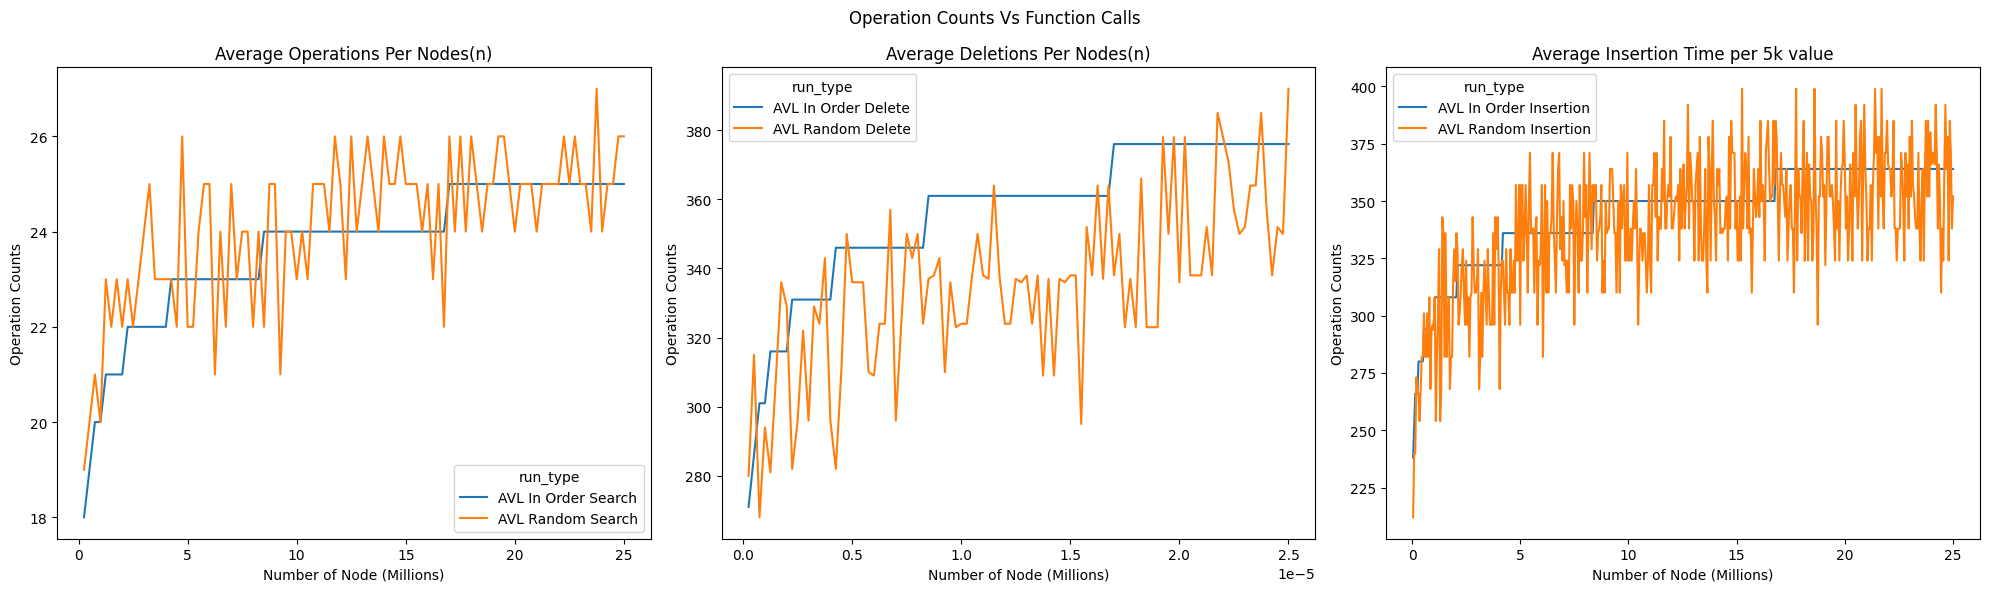

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = get_avl_data()


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

sns.lineplot(x="tree_size", y="operations_count", hue="run_type", ax=axes[0], data=data["search"])
axes[0].set_ylabel("Operation Counts")
axes[0].set_xlabel("Number of Node (Millions)")
axes[0].set_title("Average Operations Per Nodes(n)")

sns.lineplot(x="tree_size", y="ops_count", hue="run_type", ax=axes[1], data=data["delete"])
axes[1].set_ylabel("Operation Counts")
axes[1].set_xlabel("Number of Node (Millions)")
axes[1].set_title("Average Deletions Per Nodes(n)")



sns.lineplot(x="tree_size", y="operation_count", hue="run_type", ax=axes[2], data=data["insert"])
axes[2].set_ylabel("Operation Counts")
axes[2].set_xlabel("Number of Node (Millions)")
axes[2].set_title("Average Insertion Time per 5k value")

plt.suptitle("Operation Counts Vs Function Calls")
plt.tight_layout()
plt.savefig("data/plots/ops_vs_func.png")
plt.show()

# Height

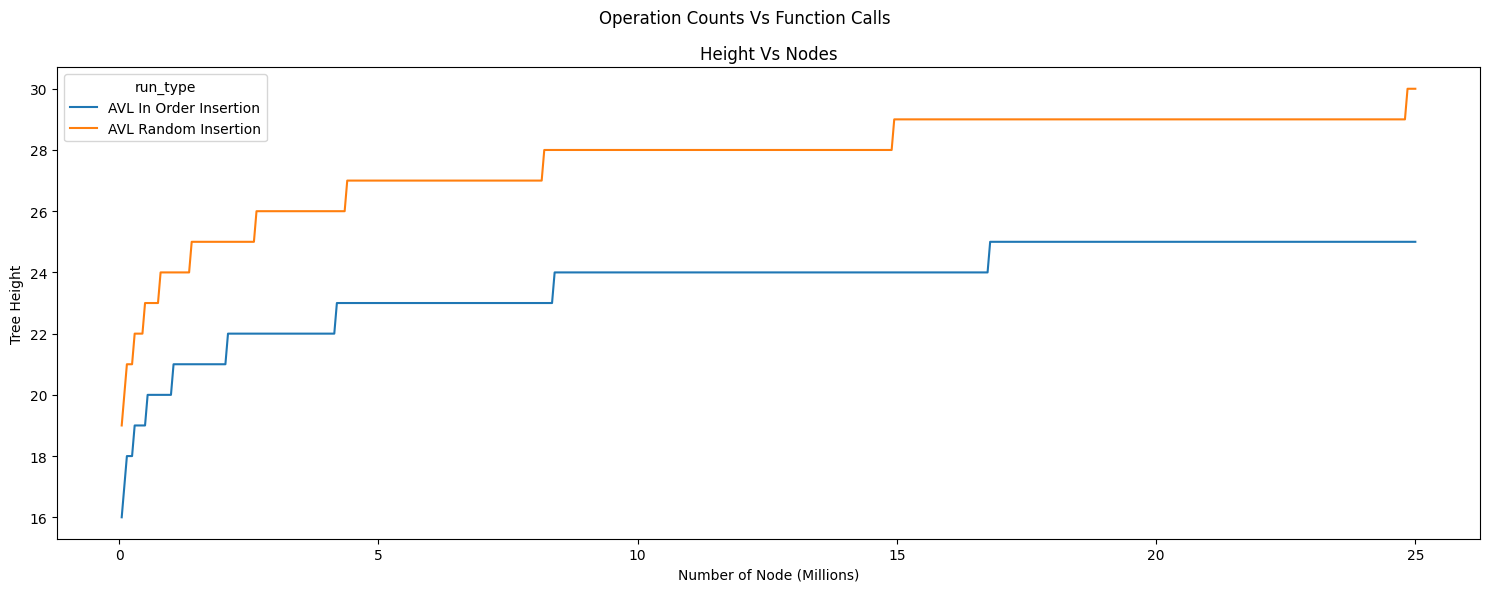

In [9]:
data = get_avl_data()


fig, axe = plt.subplots(figsize=(15, 6))

sns.lineplot(x="tree_size", y="height", hue="run_type", ax=axe, data=data["insert"])
axe.set_ylabel("Tree Height")
axe.set_xlabel("Number of Node (Millions)")
axe.set_title("Height Vs Nodes")
plt.suptitle("Operation Counts Vs Function Calls")
plt.tight_layout()
plt.savefig("data/plots/height.png")
plt.show()


# Rotations

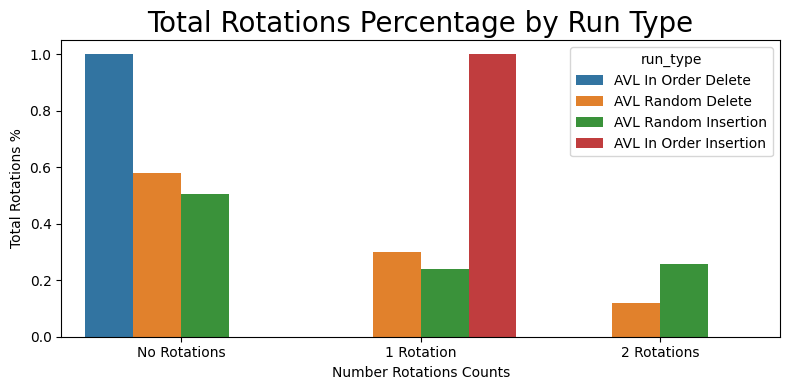

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# data = get_avl_data()
delete_rotations = data["delete"].groupby(["rotations", "run_type"], as_index=False)["id"].count()
insert_rotations = data["insert"].groupby([" rotations", "run_type"], as_index=False)["id"].count()
insert_rotations.rename(columns={" rotations": "rotations"}, inplace=True)
insert_rotations.rename(columns={"id": "count"}, inplace=True)
delete_rotations.rename(columns={"id": "count"}, inplace=True)

# Combine the two datasets
combined_rotations = pd.concat([delete_rotations, insert_rotations], ignore_index=True)
combined_rotations['rotations'] = combined_rotations['rotations'].apply(
    lambda r: "3+ Rotations" if r >= 3 
    else "2 Rotations" if r == 2
    else "1 Rotation" if r == 1
    else "No Rotations"
)
rot_cnt = combined_rotations.groupby("run_type", as_index=False)["count"].sum()
combined_rotations = combined_rotations.merge(rot_cnt, on="run_type", how="left", suffixes=('', '_total'))

combined_rotations["Total Rotations %"] = combined_rotations["count"] / combined_rotations["count_total"]
fig, axe = plt.subplots(figsize=(8, 4))

sns.barplot(y="Total Rotations %", x="rotations", hue="run_type", ax=axe, data=combined_rotations)
# axe.set_ylabel("Number Rotations Counts")

axe.set_xlabel("Number Rotations Counts", fontsize=10)
axe.set_ylabel("Total Rotations %", fontsize=10)
axe.set_title("Total Rotations Percentage by Run Type", fontsize=20)



plt.tight_layout()
plt.savefig("data/plots/rotations_vs_func.png")
plt.show()

# Comparing BSTs Run Time

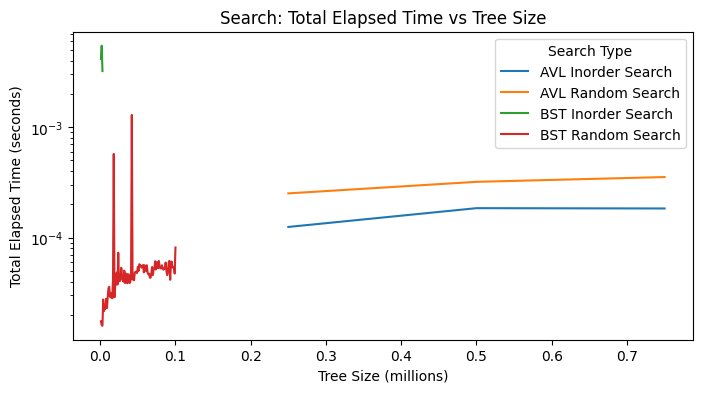

In [41]:
avl_search = get_avl_data()["search"]
bin_search = get_bin_data()["search"]




search_df = pd.concat([avl_search, bin_search])
search_df = search_df[search_df["total_elapsed_time"]< .01]
search_df = search_df[search_df["tree_size"]< 1]


fig, axe = plt.subplots(figsize=(8, 4))

sns.lineplot(x="tree_size", y="total_elapsed_time", hue="run_type", data=search_df, ax=axe)
axe.set_yscale('log') 
axe.set_ylabel("Total Elapsed Time (seconds)")
axe.set_xlabel("Tree Size (millions)")
plt.title("Search: Total Elapsed Time vs Tree Size")
plt.legend(title="Search Type")

# Model Fit

In [13]:
import numpy as np
import statsmodels.api as sm

df = get_avl_data()["insert"]
df = df[df["run_type"] != "AVL In Order Insertion"]


df["log_n"] = np.log(df["tree_size"])

X = sm.add_constant(df["log_n"])
y = df["operation_count"]

model = sm.OLS(y, X).fit()
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:        operation_count   R-squared:                       0.529
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     558.8
Date:                Sat, 29 Nov 2025   Prob (F-statistic):           2.15e-83
Time:                        19:45:24   Log-Likelihood:                -2201.8
No. Observations:                 500   AIC:                             4408.
Df Residuals:                     498   BIC:                             4416.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        291.3350      2.210    131.819      0.0

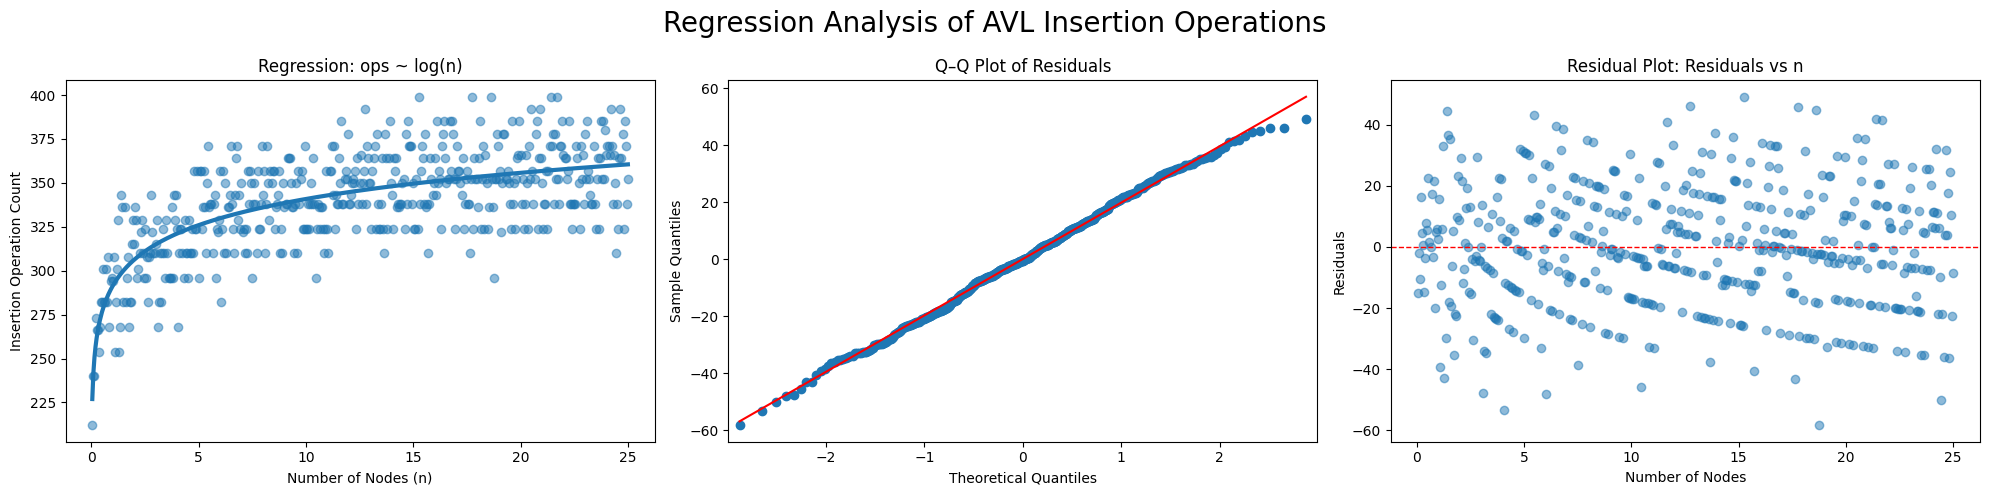

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# Line Fit
axs[0].scatter(df["tree_size"], df["operation_count"], alpha=0.5)
x_range = np.linspace(df["tree_size"].min(), df["tree_size"].max(), 500)
pred = model.predict(sm.add_constant(np.log(x_range)))

axs[0].plot(x_range, pred, linewidth=3)
axs[0].set_xlabel("Number of Nodes (n)")
axs[0].set_ylabel("Insertion Operation Count")
axs[0].set_title("Regression: ops ~ log(n)")

# QQ plot
sm.qqplot(model.resid, line='s', ax=axs[1])
axs[1].set_title("Q–Q Plot of Residuals")


# Residual Plot
axs[2].scatter(df["tree_size"], model.resid, alpha=0.5)
axs[2].axhline(0, color='red', linestyle='--', linewidth=1)
axs[2].set_xlabel("Number of Nodes")
axs[2].set_ylabel("Residuals")
axs[2].set_title("Residual Plot: Residuals vs n")
plt.suptitle("Regression Analysis of AVL Insertion Operations", fontsize=20)

plt.tight_layout()
plt.savefig("data/plots/regression_analysis.png")
plt.show()
